# Phenolics Concentration + Analysis Notebook

This notebook follows a project-style flow:
1. Load raw phenolics absorbance data
2. Build per-date/per-lab-rep calibration lines
3. Estimate gallic concentrations for non-standard samples
4. Parse sample IDs into long-term and acute experiments
5. Run paired-difference analyses (`heat - control`) and mixed-effects models
6. Preview report outputs
7. Save only final analysis outputs in the last cell


In [2]:
from datetime import datetime
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import statsmodels.formula.api as smf
from scipy import stats

ip = None
try:
    from IPython import get_ipython
    ip = get_ipython()
except Exception:
    ip = None
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')


ROOT = Path.cwd().resolve()
if not (ROOT / 'cranberry-data-group6').exists() and (ROOT.parent / 'cranberry-data-group6').exists():
    ROOT = ROOT.parent

RAW_XLSX = ROOT / 'cranberry-data-group6' / 'data_mixed' / 'Phenolics_RawData.xlsx'
RESULT_DIR = ROOT / 'results' / 'phenolics'
FIG_DIR = RESULT_DIR / 'figures'

LT_SUMMARY_OUT = RESULT_DIR / 'phenolics_longterm_summary.csv'
ACUTE_SUMMARY_OUT = RESULT_DIR / 'phenolics_acute_summary.csv'
LT_COEF_OUT = RESULT_DIR / 'phenolics_longterm_mixedlm_coefficients.csv'
ACUTE_COEF_OUT = RESULT_DIR / 'phenolics_acute_mixedlm_coefficients.csv'
LT_WALD_OUT = RESULT_DIR / 'phenolics_longterm_mixedlm_wald_terms.csv'
ACUTE_WALD_OUT = RESULT_DIR / 'phenolics_acute_mixedlm_wald_terms.csv'
REPORT_OUT = RESULT_DIR / 'phenolics_analysis_report.md'

FIG1_OUT = FIG_DIR / 'phenolics_longterm_concentration_diff.png'
FIG2_OUT = FIG_DIR / 'phenolics_acute_concentration_diff_boxplot.png'

STD_TUBES = {0, 50, 100, 150, 250, 500, 750}
REP_ABS_COLS = ['Rep1 Absorbance 765 nm', 'Rep2 Absorbance 765 nm', 'Rep3 Absorbance 765 nm']
REP_CONC_COLS = ['concentration_rep1', 'concentration_rep2', 'concentration_rep3']

LT_SET_MAP = {
    ('St', 1): 7, ('St', 2): 8, ('St', 3): 9, ('St', 4): 10,
    ('St', 5): 7, ('St', 6): 8, ('St', 7): 9, ('St', 8): 10,
    ('MQ', 9): 11, ('MQ', 10): 12, ('MQ', 11): 13, ('MQ', 12): 14,
    ('MQ', 13): 11, ('MQ', 14): 12, ('MQ', 15): 13, ('MQ', 16): 14,
}

print('ROOT:', ROOT)
print('RAW_XLSX exists:', RAW_XLSX.exists())


ROOT: /Users/liyuang/Desktop/STAT628/installment3
RAW_XLSX exists: True


In [3]:
def parse_sample_id(sample_id: str) -> dict[str, object] | None:
    s = str(sample_id).strip().upper()

    # Long-term IDs like MQLT16, STLT3
    m = re.match(r'^(ST|MQ)LT(\d+)$', s)
    if m:
        cultivar = 'St' if m.group(1) == 'ST' else 'MQ'
        plot_id = int(m.group(2))
        if cultivar == 'St':
            heat_trt = 'OTC' if plot_id in {1, 2, 3, 4} else 'Control'
        else:
            heat_trt = 'OTC' if plot_id in {9, 10, 11, 12} else 'Control'
        return {
            'experiment': 'longterm',
            'cultivar': cultivar,
            'plot_id': plot_id,
            'set_id': LT_SET_MAP.get((cultivar, plot_id)),
            'treatment_raw': heat_trt,
            'heat_level': np.nan,
            'is_control': 1 if heat_trt == 'Control' else 0,
            'replicate': np.nan,
        }

    # Acute IDs like MQA1, MQAC2, STA01, STA0C3, STCD3 (typo alias for STDC3)
    m = re.match(r'^(ST|MQ)(A0C|A0|AC|A|BC|B|CC|C|DC|CD|D)(\d+)$', s)
    if m:
        cultivar = 'St' if m.group(1) == 'ST' else 'MQ'
        trt = m.group(2)
        replicate = int(m.group(3))

        if trt == 'CD':
            trt = 'DC'

        control_tokens = {'A0C', 'AC', 'BC', 'CC', 'DC'}
        if trt in control_tokens:
            is_control = 1
            heat_level = trt[:-1]
        else:
            is_control = 0
            heat_level = trt

        return {
            'experiment': 'acute',
            'cultivar': cultivar,
            'plot_id': np.nan,
            'set_id': np.nan,
            'treatment_raw': trt,
            'heat_level': heat_level,
            'is_control': is_control,
            'replicate': replicate,
        }

    return None


def paired_ttest_table(df: pd.DataFrame, group_cols: list[str], value_col: str) -> pd.DataFrame:
    rows = []
    grouped = [(("overall",), df)] if not group_cols else list(df.groupby(group_cols))
    for key, sub in grouped:
        if not isinstance(key, tuple):
            key = (key,)
        vals = sub[value_col].dropna().to_numpy()
        if len(vals) < 2:
            t_stat, p_value, se = np.nan, np.nan, np.nan
        else:
            t_stat, p_value = stats.ttest_1samp(vals, 0.0)
            se = vals.std(ddof=1) / np.sqrt(len(vals))
        row = {
            'n_pairs': int(len(vals)),
            'mean_diff_heat_minus_control': float(np.nanmean(vals)) if len(vals) else np.nan,
            'sd_diff': float(np.nanstd(vals, ddof=1)) if len(vals) > 1 else np.nan,
            'se_diff': se,
            't_stat': t_stat,
            'p_value': p_value,
        }
        for col, value in zip(group_cols, key):
            row[col] = value
        rows.append(row)
    cols = group_cols + ['n_pairs', 'mean_diff_heat_minus_control', 'sd_diff', 'se_diff', 't_stat', 'p_value']
    return pd.DataFrame(rows)[cols]


def fit_mixedlm(formula: str, data: pd.DataFrame, group_col: str):
    methods = ['lbfgs', 'powell', 'cg', 'nm']
    fallback = None
    errors = []
    for method in methods:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                model = smf.mixedlm(formula, data=data, groups=data[group_col]).fit(
                    reml=False,
                    method=method,
                    maxiter=1000,
                    disp=False,
                )
            if model.converged:
                return model, method
            if fallback is None:
                fallback = (model, method)
        except Exception as exc:
            errors.append(f'{method}: {exc}')
    if fallback is not None:
        return fallback
    raise RuntimeError('MixedLM failed for all optimizers: ' + ' | '.join(errors))


def mixedlm_coefficient_table(model, model_name: str, optimizer: str) -> pd.DataFrame:
    ci = model.conf_int()
    return pd.DataFrame(
        {
            'model_name': model_name,
            'optimizer': optimizer,
            'term': model.params.index,
            'estimate': model.params.values,
            'std_error': model.bse.values,
            'z_value': model.tvalues.values,
            'p_value': model.pvalues.values,
            'ci_low': ci[0].values,
            'ci_high': ci[1].values,
            'n_obs': int(model.nobs),
            'n_groups': int(len(model.model.group_labels)),
            'converged': bool(model.converged),
            'log_likelihood': float(model.llf),
            'aic': float(model.aic),
            'bic': float(model.bic),
        }
    )


def _scalar(value) -> float:
    arr = np.asarray(value).astype(float).reshape(-1)
    return float(arr[0]) if arr.size else np.nan


def mixedlm_wald_terms_table(model, model_name: str) -> pd.DataFrame:
    table = model.wald_test_terms(skip_single=False).table.reset_index().rename(columns={'index': 'term'})
    p_col = 'pvalue' if 'pvalue' in table.columns else 'p_value'
    return pd.DataFrame(
        {
            'model_name': model_name,
            'term': table['term'],
            'statistic': table['statistic'].map(_scalar),
            'df_constraint': table['df_constraint'].map(_scalar),
            'p_value': table[p_col].map(_scalar),
        }
    )


## 1) Load raw absorbance data and classify standards


In [4]:
raw = pd.read_excel(RAW_XLSX, sheet_name='Absorbance Data').copy()
raw['sample_id_clean'] = raw['Sample ID'].astype(str).str.strip()
raw['tube_num'] = pd.to_numeric(raw['Tube#'], errors='coerce')
raw['date_key'] = pd.to_datetime(raw['Date'], errors='coerce').dt.normalize()

# Important fix: only treat Std* rows as true standards if Tube# is one of the known standard concentrations.
raw['is_standard'] = raw['sample_id_clean'].str.match(r'(?i)^std\d+$', na=False) & raw['tube_num'].isin(STD_TUBES)

print('Raw rows:', len(raw))
print('Standard rows:', int(raw['is_standard'].sum()))
print('Non-standard rows:', int((~raw['is_standard']).sum()))

suspicious_std = raw[raw['sample_id_clean'].str.match(r'(?i)^std\d+$', na=False) & ~raw['tube_num'].isin(STD_TUBES)].copy()
print('Std-like IDs that are NOT true standards:', len(suspicious_std))
suspicious_std[['Date', 'Sample ID', 'Tube#']]


Raw rows: 128
Standard rows: 49
Non-standard rows: 79
Std-like IDs that are NOT true standards: 3


,Date,Sample ID,Tube#
21,2025-01-07,STD1,8
48,2025-01-08,STD3,28
97,2025-01-13,STD2,63


## 2) Fit calibration lines for each Date x lab replicate


In [5]:
calibration_rows = []
calibration_lookup = {}

std = raw[raw['is_standard']].copy()
for rep_idx, abs_col in enumerate(REP_ABS_COLS, start=1):
    for date, sub in std.groupby('date_key'):
        x = pd.to_numeric(sub['tube_num'], errors='coerce').to_numpy(dtype=float)
        y = pd.to_numeric(sub[abs_col], errors='coerce').to_numpy(dtype=float)
        keep = np.isfinite(x) & np.isfinite(y)
        x = x[keep]
        y = y[keep]

        if len(x) < 2:
            m, b = np.nan, np.nan
        else:
            m, b = np.polyfit(x, y, 1)

        calibration_lookup[(date, rep_idx)] = (float(m), float(b))
        calibration_rows.append(
            {
                'Date': date,
                'replicate': rep_idx,
                'n_standards': int(len(x)),
                'slope_m': float(m),
                'intercept_b': float(b),
            }
        )

calibration_summary = pd.DataFrame(calibration_rows).sort_values(['Date', 'replicate']).reset_index(drop=True)
print('Calibration lines:', len(calibration_summary))
calibration_summary.head(12)


Calibration lines: 21


,Date,replicate,n_standards,slope_m,intercept_b
0,2025-01-06,1,7,0.000981,0.019741
1,2025-01-06,2,7,0.001025,0.027968
2,2025-01-06,3,7,0.001081,0.012508
3,2025-01-07,1,7,0.000949,0.027288
4,2025-01-07,2,7,0.001025,0.011029
5,2025-01-07,3,7,0.001028,0.014722
6,2025-01-08,1,7,0.000999,0.006875
7,2025-01-08,2,7,0.001014,0.008022
8,2025-01-08,3,7,0.001017,0.000013
9,2025-01-09,1,7,0.001004,-0.006946


## 3) Estimate concentrations for non-standard rows


In [6]:
nonstd = raw[~raw['is_standard']].copy().reset_index(drop=True)

for rep_idx, abs_col in enumerate(REP_ABS_COLS, start=1):
    out_col = REP_CONC_COLS[rep_idx - 1]
    vals = []
    for _, r in nonstd.iterrows():
        m, b = calibration_lookup.get((r['date_key'], rep_idx), (np.nan, np.nan))
        y = pd.to_numeric(r[abs_col], errors='coerce')
        if (not np.isfinite(m)) or (m == 0) or (not np.isfinite(y)):
            vals.append(np.nan)
        else:
            vals.append(((y - b) / m) * 10.0)
    nonstd[out_col] = vals

concentrations = nonstd[['date_key', 'Sample ID', 'Tube#'] + REP_CONC_COLS].copy()
concentrations = concentrations.rename(columns={'date_key': 'Date'})
concentrations['Date'] = pd.to_datetime(concentrations['Date'], errors='coerce').dt.strftime('%Y-%m-%d')

print('Output rows (non-standard only):', len(concentrations))
print('Missing concentration cells:', int(concentrations[REP_CONC_COLS].isna().sum().sum()))
concentrations.head(12)


Output rows (non-standard only): 79
Missing concentration cells: 0


,Date,Sample ID,Tube#,concentration_rep1,concentration_rep2,concentration_rep3
0,2025-01-06,STB3,1,1511.292765,1288.658829,1308.466163
1,2025-01-06,MQBC2,2,2214.652098,1308.179239,2353.448658
2,2025-01-06,MQLT16,3,1888.456465,2596.526240,1641.380940
3,2025-01-06,STA0C1,4,991.418476,1015.373102,2205.486535
4,2025-01-06,MQA03,5,1409.356630,1776.669057,2048.276779
5,2025-01-06,MQAC1,6,1970.005374,2147.556831,1752.352533
6,2025-01-06,MQCC1,7,1654.003354,1425.301693,1576.647512
7,2025-01-07,STD1,8,1187.845118,1658.436984,1627.617079
8,2025-01-07,MQLT9,9,1746.397306,1473.050906,1705.457202
9,2025-01-07,STLT6,10,1303.771044,1531.593878,1637.347094


## 4) Parse sample IDs and build analysis-ready phenolics table


In [7]:
parsed = concentrations['Sample ID'].apply(parse_sample_id)
parsed_df = pd.DataFrame([x if isinstance(x, dict) else {} for x in parsed])

phen = pd.concat([concentrations, parsed_df], axis=1)
phen['mean_concentration'] = phen[REP_CONC_COLS].mean(axis=1, skipna=True)

print('Rows parsed successfully:', int(phen['experiment'].notna().sum()), '/', len(phen))
print('Rows by experiment:')
print(phen['experiment'].value_counts(dropna=False))

phen[['Date', 'Sample ID', 'experiment', 'cultivar', 'treatment_raw', 'heat_level', 'is_control', 'replicate', 'mean_concentration']].head(20)


Rows parsed successfully: 79 / 79
Rows by experiment:
experiment
acute       63
longterm    16
Name: count, dtype: int64


,Date,Sample ID,experiment,cultivar,treatment_raw,heat_level,is_control,replicate,mean_concentration
0,2025-01-06,STB3,acute,St,B,B,0,3.0,1369.472586
1,2025-01-06,MQBC2,acute,MQ,BC,B,1,2.0,1958.759998
2,2025-01-06,MQLT16,longterm,MQ,Control,NaN,1,NaN,2042.121215
3,2025-01-06,STA0C1,acute,St,A0C,A0,1,1.0,1404.092704
4,2025-01-06,MQA03,acute,MQ,A0,A0,0,3.0,1744.767489
5,2025-01-06,MQAC1,acute,MQ,AC,A,1,1.0,1956.638246
6,2025-01-06,MQCC1,acute,MQ,CC,C,1,1.0,1551.984186
7,2025-01-07,STD1,acute,St,D,D,0,1.0,1491.299727
8,2025-01-07,MQLT9,longterm,MQ,OTC,NaN,0,NaN,1641.635138
9,2025-01-07,STLT6,longterm,St,Control,NaN,1,NaN,1490.904005


## 5) Long-term and acute paired differences (heat - control)


In [8]:
# Long-term
lt = phen[phen['experiment'] == 'longterm'].copy()
lt_agg = (
    lt.groupby(['cultivar', 'set_id', 'treatment_raw'], as_index=False)['mean_concentration']
    .mean()
)
lt_pairs = (
    lt_agg.pivot(index=['cultivar', 'set_id'], columns='treatment_raw', values='mean_concentration')
    .reset_index()
    .rename_axis(columns=None)
)
lt_pairs['concentration_diff'] = lt_pairs['OTC'] - lt_pairs['Control']

# Acute (exclude A0 / A0C by heat_level filter)
acute = phen[(phen['experiment'] == 'acute') & (phen['heat_level'] != 'A0')].copy()

acute_dup_before = (
    acute.groupby(['cultivar', 'heat_level', 'replicate', 'is_control'])
    .size()
    .reset_index(name='n_rows')
    .query('n_rows > 1')
)

acute_agg = (
    acute.groupby(['cultivar', 'heat_level', 'replicate', 'is_control'], as_index=False)['mean_concentration']
    .mean()
)
acute_pairs = (
    acute_agg.pivot(index=['cultivar', 'heat_level', 'replicate'], columns='is_control', values='mean_concentration')
    .reset_index()
    .rename_axis(columns=None)
    .rename(columns={0: 'heat', 1: 'control'})
)
acute_pairs['concentration_diff'] = acute_pairs['heat'] - acute_pairs['control']
acute_pairs['complete_pair'] = (acute_pairs[['heat', 'control']].notna().all(axis=1)).astype(int)

print('Long-term pairs:', len(lt_pairs))
print('Acute pairs:', len(acute_pairs), '| complete:', int(acute_pairs['complete_pair'].sum()))
print('\nAcute duplicated keys before aggregation:')
print(acute_dup_before if len(acute_dup_before) else 'None')

lt_pairs



Long-term pairs: 8
Acute pairs: 24 | complete: 24

Acute duplicated keys before aggregation:
   cultivar heat_level  replicate  is_control  n_rows
15       MQ          C        2.0           1       2
47       St          D        3.0           1       2


,cultivar,set_id,Control,OTC,concentration_diff
0,MQ,11.0,1635.537926,1641.635138,6.097212
1,MQ,12.0,1827.682900,1884.087978,56.405078
2,MQ,13.0,1642.958686,2146.766006,503.807320
3,MQ,14.0,2042.121215,2301.907346,259.786131
4,St,7.0,1506.510232,1050.685682,-455.824550
5,St,8.0,1490.904005,1523.944374,33.040369
6,St,9.0,1334.467151,1269.231574,-65.235577
7,St,10.0,1733.031331,1722.619152,-10.412180


In [9]:
acute_pairs.sort_values(['cultivar', 'heat_level', 'replicate'])


,cultivar,heat_level,replicate,heat,control,concentration_diff,complete_pair
0,MQ,A,1.0,2027.409284,1956.638246,70.771038,1
1,MQ,A,2.0,1614.026674,2709.018189,-1094.991516,1
2,MQ,A,3.0,1891.078119,1873.119146,17.958973,1
3,MQ,B,1.0,1703.556651,1732.332322,-28.775671,1
4,MQ,B,2.0,1770.316422,1958.759998,-188.443577,1
5,MQ,B,3.0,1432.333337,1603.751690,-171.418354,1
6,MQ,C,1.0,1697.681915,1551.984186,145.697729,1
7,MQ,C,2.0,1314.764466,1802.576563,-487.812097,1
8,MQ,C,3.0,2097.997198,1711.085406,386.911792,1
9,MQ,D,1.0,1684.868456,1555.776590,129.091866,1


## 6) Statistical summaries and mixed-effects models


In [10]:
lt_complete = lt_pairs.dropna(subset=['concentration_diff']).copy()
acute_complete = acute_pairs[acute_pairs['complete_pair'] == 1].copy()

lt_summary_by_cv = paired_ttest_table(lt_complete, ['cultivar'], 'concentration_diff')
lt_summary_overall = paired_ttest_table(lt_complete, [], 'concentration_diff')
lt_summary = pd.concat([lt_summary_overall, lt_summary_by_cv], ignore_index=True, sort=False)

acute_summary_by = paired_ttest_table(acute_complete, ['cultivar', 'heat_level'], 'concentration_diff')
acute_summary_over = paired_ttest_table(acute_complete, ['heat_level'], 'concentration_diff')
acute_summary = pd.concat([acute_summary_over, acute_summary_by], ignore_index=True, sort=False)

# Mixed-effects models on row-level concentrations
lt_model_df = lt.dropna(subset=['mean_concentration', 'set_id', 'cultivar', 'treatment_raw']).copy()
lt_model_df['set_id'] = pd.to_numeric(lt_model_df['set_id'], errors='coerce').astype('Int64')
lt_model_df = lt_model_df[lt_model_df['set_id'].notna()].copy()
lt_model_df['set_key'] = lt_model_df['cultivar'].astype(str) + '_' + lt_model_df['set_id'].astype(str)

lt_model, lt_optimizer = fit_mixedlm(
    'mean_concentration ~ C(cultivar) * C(treatment_raw)',
    lt_model_df,
    'set_key',
)
lt_coef = mixedlm_coefficient_table(lt_model, 'longterm_mixedlm', lt_optimizer)
lt_terms = mixedlm_wald_terms_table(lt_model, 'longterm_mixedlm')

acute_complete_keys = acute_pairs.loc[
    acute_pairs['complete_pair'] == 1,
    ['cultivar', 'heat_level', 'replicate']
].drop_duplicates()
acute_model_df = acute_agg.merge(
    acute_complete_keys,
    on=['cultivar', 'heat_level', 'replicate'],
    how='inner',
)
acute_model_df = acute_model_df.dropna(subset=['mean_concentration']).copy()
acute_model_df['pair_id'] = (
    acute_model_df['cultivar'].astype(str)
    + '_'
    + acute_model_df['heat_level'].astype(str)
    + '_'
    + acute_model_df['replicate'].astype(str)
)

acute_model, acute_optimizer = fit_mixedlm(
    'mean_concentration ~ C(heat_level) * C(cultivar) * C(is_control)',
    acute_model_df,
    'pair_id',
)
acute_coef = mixedlm_coefficient_table(acute_model, 'acute_mixedlm', acute_optimizer)
acute_terms = mixedlm_wald_terms_table(acute_model, 'acute_mixedlm')

print('Long-term complete pairs:', len(lt_complete), '| model rows:', len(lt_model_df))
print('Acute complete pairs:', len(acute_complete), '| model rows:', len(acute_model_df))

lt_summary


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1906: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


Long-term complete pairs: 8 | model rows: 16
Acute complete pairs: 24 | model rows: 48


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1906: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


,n_pairs,mean_diff_heat_minus_control,sd_diff,se_diff,t_stat,p_value,cultivar
0,8,40.957975,273.689264,96.763767,0.423278,0.684794,NaN
1,4,206.523935,226.510349,113.255175,1.823528,0.165736,MQ
2,4,-124.607984,224.442406,112.221203,-1.110378,0.347830,St


In [11]:
acute_summary


,heat_level,n_pairs,mean_diff_heat_minus_control,sd_diff,se_diff,t_stat,p_value,cultivar
0,A,6,8.168373,639.751417,261.177423,0.031275,0.976260,NaN
1,B,6,-54.569416,199.428603,81.416386,-0.670251,0.532404,NaN
2,C,6,-84.880297,318.895467,130.188529,-0.651980,0.543192,NaN
3,D,6,-150.904522,189.092593,77.196728,-1.954805,0.108004,NaN
4,A,3,-335.420501,658.337583,380.091381,-0.882473,0.470610,MQ
5,B,3,-129.545867,87.683743,50.624233,-2.558969,0.124765,MQ
6,C,3,14.932475,451.785496,260.838478,0.057248,0.959553,MQ
7,D,3,-191.496203,279.382833,161.301754,-1.187192,0.357045,MQ
8,A,3,351.757248,485.423911,280.259626,1.255112,0.336217,St
9,B,3,20.407034,273.635845,157.983729,0.129172,0.909040,St


In [12]:
lt_terms.sort_values('p_value', ascending=True)


,model_name,term,statistic,df_constraint,p_value
0,longterm_mixedlm,Intercept,290.381264,1.0,4.106602e-65
3,longterm_mixedlm,C(cultivar):C(treatment_raw),5.751211,1.0,1.647730e-02
2,longterm_mixedlm,C(treatment_raw),4.474329,1.0,3.440770e-02
1,longterm_mixedlm,C(cultivar),3.335040,1.0,6.781877e-02


In [13]:
acute_terms.sort_values('p_value', ascending=True)


,model_name,term,statistic,df_constraint,p_value
0,acute_mixedlm,Intercept,292.652994,1.0,1.313717e-65
6,acute_mixedlm,C(cultivar):C(is_control),10.566449,1.0,1.151587e-03
3,acute_mixedlm,C(is_control),5.035007,1.0,2.483998e-02
7,acute_mixedlm,C(heat_level):C(cultivar):C(is_control),9.219359,3.0,2.651218e-02
1,acute_mixedlm,C(heat_level),6.214332,3.0,1.016356e-01
2,acute_mixedlm,C(cultivar),2.336750,1.0,1.263529e-01
5,acute_mixedlm,C(heat_level):C(is_control),2.832526,3.0,4.181736e-01
4,acute_mixedlm,C(heat_level):C(cultivar),1.927258,3.0,5.876409e-01


## 7) Figures


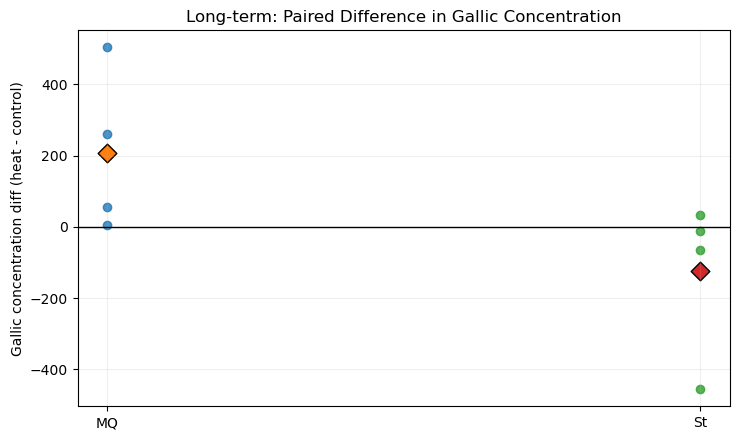

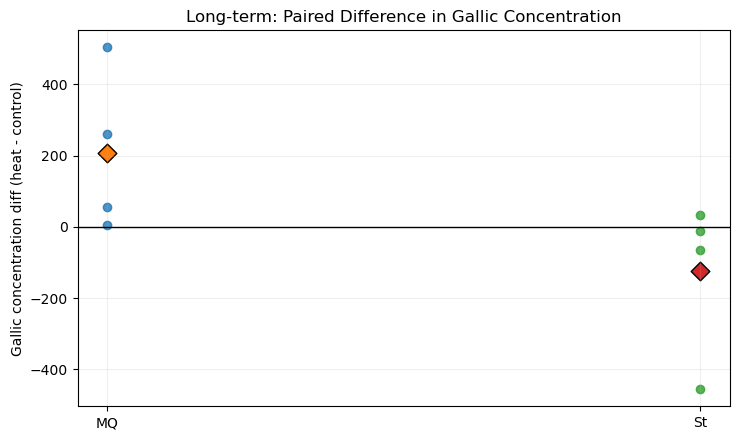

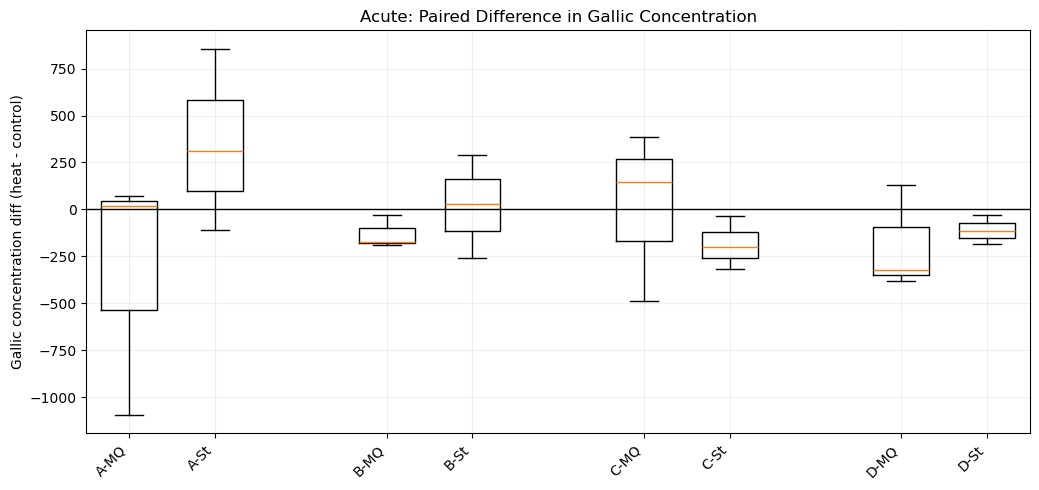

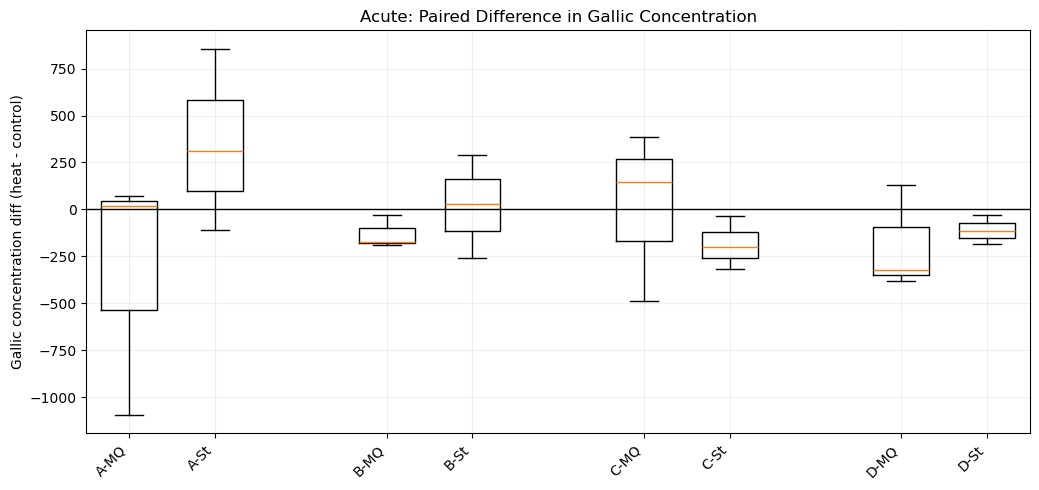

Saved figures:
- /Users/liyuang/Desktop/STAT628/installment3/results/phenolics/figures/phenolics_longterm_concentration_diff.png
- /Users/liyuang/Desktop/STAT628/installment3/results/phenolics/figures/phenolics_acute_concentration_diff_boxplot.png


In [14]:
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Figure 1: long-term paired differences by cultivar
fig1, ax1 = plt.subplots(figsize=(7.5, 4.5))
x_map = {'MQ': 0, 'St': 1}
for cv, sub in lt_complete.groupby('cultivar'):
    x = np.full(len(sub), x_map.get(cv, np.nan), dtype=float)
    ax1.scatter(x, sub['concentration_diff'], alpha=0.8, label=cv)
    ax1.scatter(x_map.get(cv, np.nan), sub['concentration_diff'].mean(), marker='D', s=90, edgecolor='black')
ax1.axhline(0, color='black', linewidth=1)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['MQ', 'St'])
ax1.set_ylabel('Gallic concentration diff (heat - control)')
ax1.set_title('Long-term: Paired Difference in Gallic Concentration')
ax1.grid(alpha=0.2)
fig1.tight_layout()
fig1.savefig(FIG1_OUT, dpi=180)
display(fig1)
plt.show()

# Figure 2: acute paired differences boxplot
fig2, ax2 = plt.subplots(figsize=(10.5, 5.0))
order = ['A', 'B', 'C', 'D']
positions, data, labels = [], [], []
for i, h in enumerate(order):
    for j, cv in enumerate(['MQ', 'St']):
        vals = acute_complete.loc[
            (acute_complete['heat_level'] == h) & (acute_complete['cultivar'] == cv),
            'concentration_diff'
        ].to_numpy()
        positions.append(i * 3 + j + 1)
        data.append(vals)
        labels.append(f'{h}-{cv}')
ax2.boxplot(data, positions=positions, widths=0.65)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_xticks(positions)
ax2.set_xticklabels(labels, rotation=45, ha='right')
ax2.set_ylabel('Gallic concentration diff (heat - control)')
ax2.set_title('Acute: Paired Difference in Gallic Concentration')
ax2.grid(alpha=0.2)
fig2.tight_layout()
fig2.savefig(FIG2_OUT, dpi=180)
display(fig2)
plt.show()

print('Saved figures:')
print('-', FIG1_OUT)
print('-', FIG2_OUT)


## 8) Preview report text


In [15]:
std_like_nonstd = raw[
    raw['sample_id_clean'].str.match(r'(?i)^std\d+$', na=False)
    & ~raw['tube_num'].isin(STD_TUBES)
]

def best_term_line(df: pd.DataFrame, label: str) -> str:
    sub = df[(df['term'] != 'Intercept')].dropna(subset=['p_value']).copy()
    if sub.empty:
        return f'- {label}: no valid term test'
    best = sub.sort_values('p_value', ascending=True).iloc[0]
    return f"- {label}: smallest term p={best['p_value']:.4g} ({best['term']})"

report_lines = [
    '# Phenolics Analysis Report',
    '',
    f'- Generated at: {datetime.now().isoformat(timespec="seconds")}',
    '- Outcome coding: all concentration differences are `heat - control`.',
    '- Acute A0/A0C rows were excluded from treatment-effect analysis.',
    '- Primary models: mixed-effects models on row-level concentration data.',
    '',
    '## Inputs',
    f'- {RAW_XLSX}',
    '',
    '## Calibration and concentration estimation',
    f'- Standards identified: {int(raw["is_standard"].sum())}',
    f'- Non-standard rows estimated: {len(concentrations)}',
    f'- Std-like non-standard rows retained (e.g., STD1): {len(std_like_nonstd)}',
    '',
    '## Pair counts',
    f'- Long-term pairs: {len(lt_complete)}',
    f'- Acute complete pairs: {len(acute_complete)}',
    f'- Acute pairs missing one side: {int((acute_pairs["complete_pair"] == 0).sum())}',
    '',
    '## Paired-summary quick check',
    '- Long-term concentration summary:',
]

for _, row in lt_summary.fillna('').iterrows():
    label = row['cultivar'] if row.get('cultivar', '') else 'overall'
    report_lines.append(f"  - {label}: mean diff={row['mean_diff_heat_minus_control']:.3f}, p={row['p_value'] if row['p_value'] != '' else np.nan}")

report_lines.append('- Acute concentration summary by heat level:')
for _, row in acute_summary.fillna('').iterrows():
    label = (
        f"{row['cultivar']}-{row['heat_level']}"
        if row.get('cultivar', '') and row.get('heat_level', '')
        else row.get('heat_level', 'overall')
    )
    report_lines.append(f"  - {label}: mean diff={row['mean_diff_heat_minus_control']:.3f}, p={row['p_value'] if row['p_value'] != '' else np.nan}")

report_lines.extend([
    '',
    '## Mixed-model findings',
    best_term_line(lt_terms, 'Long-term concentration model'),
    best_term_line(acute_terms, 'Acute concentration model'),
    '',
    '## Outputs',
    f'- {LT_SUMMARY_OUT}',
    f'- {ACUTE_SUMMARY_OUT}',
    f'- {LT_COEF_OUT}',
    f'- {ACUTE_COEF_OUT}',
    f'- {LT_WALD_OUT}',
    f'- {ACUTE_WALD_OUT}',
    f'- {FIG1_OUT}',
    f'- {FIG2_OUT}',
    f'- {REPORT_OUT}',
    '',
])

print('\n'.join(report_lines[:40]))


# Phenolics Analysis Report

- Generated at: 2026-03-19T12:47:19
- Outcome coding: all concentration differences are `heat - control`.
- Acute A0/A0C rows were excluded from treatment-effect analysis.
- Primary models: mixed-effects models on row-level concentration data.

## Inputs
- /Users/liyuang/Desktop/STAT628/installment3/cranberry-data-group6/data_mixed/Phenolics_RawData.xlsx

## Calibration and concentration estimation
- Standards identified: 49
- Non-standard rows estimated: 79
- Std-like non-standard rows retained (e.g., STD1): 3

## Pair counts
- Long-term pairs: 8
- Acute complete pairs: 24
- Acute pairs missing one side: 0

## Paired-summary quick check
- Long-term concentration summary:
  - overall: mean diff=40.958, p=0.6847936480609327
  - MQ: mean diff=206.524, p=0.16573608585121863
  - St: mean diff=-124.608, p=0.3478302208766053
- Acute concentration summary by heat level:
  - A: mean diff=8.168, p=0.976260101929666
  - B: mean diff=-54.569, p=0.532404229275772
  - C

## 9) Final step: write outputs


In [16]:
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

lt_summary.to_csv(LT_SUMMARY_OUT, index=False)
acute_summary.to_csv(ACUTE_SUMMARY_OUT, index=False)
lt_coef.to_csv(LT_COEF_OUT, index=False)
acute_coef.to_csv(ACUTE_COEF_OUT, index=False)
lt_terms.to_csv(LT_WALD_OUT, index=False)
acute_terms.to_csv(ACUTE_WALD_OUT, index=False)

REPORT_OUT.write_text('\n'.join(report_lines), encoding='utf-8')

print('Wrote files:')
for p in [
    LT_SUMMARY_OUT,
    ACUTE_SUMMARY_OUT,
    LT_COEF_OUT,
    ACUTE_COEF_OUT,
    LT_WALD_OUT,
    ACUTE_WALD_OUT,
    FIG1_OUT,
    FIG2_OUT,
    REPORT_OUT,
]:
    print('-', p)


Wrote files:
- /Users/liyuang/Desktop/STAT628/installment3/results/phenolics/phenolics_longterm_summary.csv
- /Users/liyuang/Desktop/STAT628/installment3/results/phenolics/phenolics_acute_summary.csv
- /Users/liyuang/Desktop/STAT628/installment3/results/phenolics/phenolics_longterm_mixedlm_coefficients.csv
- /Users/liyuang/Desktop/STAT628/installment3/results/phenolics/phenolics_acute_mixedlm_coefficients.csv
- /Users/liyuang/Desktop/STAT628/installment3/results/phenolics/phenolics_longterm_mixedlm_wald_terms.csv
- /Users/liyuang/Desktop/STAT628/installment3/results/phenolics/phenolics_acute_mixedlm_wald_terms.csv
- /Users/liyuang/Desktop/STAT628/installment3/results/phenolics/figures/phenolics_longterm_concentration_diff.png
- /Users/liyuang/Desktop/STAT628/installment3/results/phenolics/figures/phenolics_acute_concentration_diff_boxplot.png
- /Users/liyuang/Desktop/STAT628/installment3/results/phenolics/phenolics_analysis_report.md
